In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
numeric_df = df.select_dtypes(include=np.number)


Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1


df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
                 (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q


In [10]:

numeric_df = df_clean.select_dtypes(include=np.number)


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = scaler.fit_transform(numeric_df)


df_minmax = pd.DataFrame(df_minmax,
                         columns=numeric_df.columns)

df_minmax.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,0.346939,0.5,0.0,0.118512
1,0.002247,1.0,1.0,0.428571,0.0,0.0,0.129546
2,0.003371,1.0,0.0,0.612245,0.5,0.0,0.868002
3,0.004494,0.0,1.0,0.612245,0.0,0.0,0.131590
4,0.005618,0.0,1.0,0.504064,0.0,0.0,0.138264


In [11]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
df_standard = standard.fit_transform(numeric_df)

df_standard = pd.DataFrame(df_standard,
                           columns=numeric_df.columns)

df_standard.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.733575,-0.654384,0.67833,-0.909802,1.800735,0.0,-0.609448
1,-1.725863,1.528156,0.67833,-0.439745,-0.448235,0.0,-0.555858
2,-1.722007,1.528156,-2.04917,0.617882,1.800735,0.0,3.030715
3,-1.718151,-0.654384,0.67833,0.617882,-0.448235,0.0,-0.545934
4,-1.714295,-0.654384,0.67833,-0.005046,-0.448235,0.0,-0.513517


In [12]:
pca = PCA()
pca_data = pca.fit_transform(df_standard)

print(pca.explained_variance_ratio_)

[0.34672983 0.19346702 0.15637082 0.14949773 0.10868094 0.04525366
 0.        ]


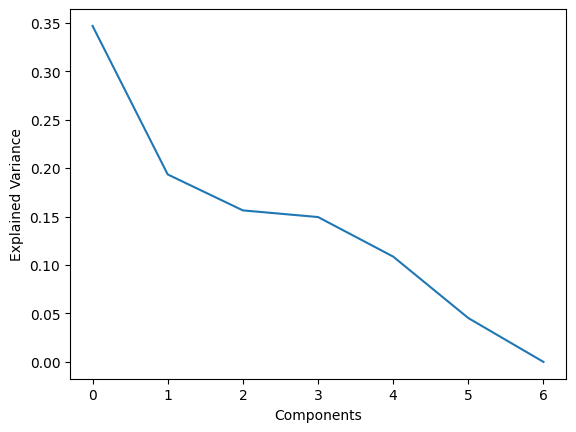

In [13]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Components")
plt.ylabel("Explained Variance")
plt.show()